# Calculate Heat Dissipation from Shims
Jeff

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import magpylib as magpy
import arc
# from get_polarizability import *
from tqdm import tqdm
import scipy

## Length Requirements
Calculated from the values at the end of https://hu.sharepoint.com/sites/NiGroup/Shared%20Documents/RbCs%202026/Projects.one#B%20Field%20Simulations&section-id={167C8F6F-19C6-4216-85F0-AF788991DC5E}&page-id={A2C1140A-7615-4173-9A5F-351C374F5781}&end

C:\Users\RbCs - Control\AppData\Local\Temp\ipykernel_52272\1949242114.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


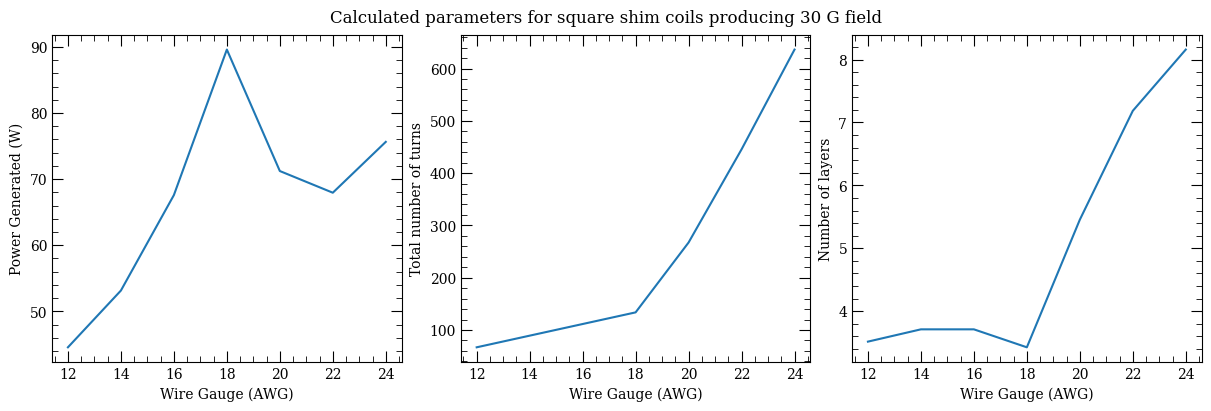

In [24]:
# We assume we'll use square coils (since they have the largest surface area + are easiest to wind)

def calculate_power(gauge, field):
    # Gauge should be supplied in AWG, Field should be supplied in Gauss, 
    #Taken from: https://en.wikipedia.org/wiki/American_wire_gauge
    wire_gauge = [24,22,20,18,16,14,12] #AWG
    ampacity = [2.1, 3, 5, 10, 12, 15, 20] #Amps
    res_per_length = [84.22, 52.96, 33.31, 20.95, 13.17, 8.286, 5.211] #miliOhms/meter
    res_per_length = np.array(res_per_length)*1e-3 #Ohms/meter

    gi = wire_gauge.index(gauge)
    I_req = (490/11)*field #490 A was required to generate 11 G in the close configuration of the square coils
    turns = I_req / ampacity[gi] #Get number of turns required to generate the field
    wire_length = turns * (80e-3*4) #Length of one coil loop in the 490A 11G square coil configuration
    power = (ampacity[gi]**2)*(res_per_length[gi]*wire_length) # P = I^2 * R
    return power, turns

def plot_for_field(field):
    gauges = [24,22,20,18,16,14,12]
    wire_diameters = np.array([0.511, 0.644, 0.812, 1.024, 1.291, 1.628, 2.053]) *1e-3
    powers = []
    turns = []
    layers = []
    for w_ind in range(len(gauges)):
        wg = gauges[w_ind]
        p,t = calculate_power(wg, field)
        powers.append(p)
        turns.append(t)
        diam = wire_diameters[w_ind]
        turns_p_layer = np.floor(40e-3/diam)
        l = t/turns_p_layer
        layers.append(l)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    axes[0].plot(gauges, powers)
    axes[0].set_xlabel("Wire Gauge (AWG)")
    axes[0].set_ylabel("Power Generated (W)")
    
    axes[1].plot(gauges, turns)
    axes[1].set_xlabel("Wire Gauge (AWG)")
    axes[1].set_ylabel("Total number of turns")

    axes[2].plot(gauges, layers)
    axes[2].set_xlabel("Wire Gauge (AWG)")
    axes[2].set_ylabel("Number of layers")

    fig.suptitle(f"Calculated parameters for square shim coils producing {field} G field")
    fig.show()

plot_for_field(30) #30 G is our worst case scenario, since our max field gradient is 30 G/cm

In [20]:
sa = (80e-3*4)*40e-3 #surface area of contact 
h_air = 5 #approximate convective heat transfer coefficient of still air in SI units
T_coil = 60 #wiki page says coils operate around 60 Celsius
T_air = 20 #Air is 20 celsius
T_water = 16 #61 Fahrenheit ~ 16 Celsius
T_ultem = 20 #Assume ultem at ambient temperature
L_ultem = 1e-2 #say we have 1 centimeter thick ultem mount
k_ultem = 0.15 #Ultem 1000 thermal conductivity in SI units
h_water = 1000 #approximate convective heat transfer coeffficient for moving water in SI units 

Q_air = h_air * sa * (T_coil - T_air)
Q_ultem = k_ultem * sa * (T_coil - T_air) / L_ultem
Q_water = h_water * sa * (T_coil - T_water)

print(f"Heat transfer rate from copper to air {Q_air:.3f} W")
print(f"Heat transfer rate from copper to air through ultem mount {Q_ultem:.3f} W")
print(f"Heat transfer rate from copper to water cooling mount {Q_water:.3f} W")


Heat transfer rate from copper to air 2.560 W
Heat transfer rate from copper to air through ultem mount 7.680 W
Heat transfer rate from copper to water cooling mount 563.200 W
